# Information in the ensemble's moments about its own signal

At each grid cell, for the ensemble $F$ of $N=49$ members over $T=120$ monthly steps,
this computes the dependence between each moment of the across-member distribution and the
ensemble mean $s$. No observations are involved.

Moments: the spread $\sigma_F$, and the standardised central moments
$m_k = \overline{(f-\bar f)^k}/\sigma_F^{\,k}$ for $k = 3,4,5,6$ ($m_3$ skewness,
$m_4$ kurtosis).

Each is reported three ways -- $\lambda$ from the raw MI, $\lambda$ from the
null-corrected MI, and Pearson $r$ -- and twice over: on the data as it comes, and after
removing the month-of-year climatology from both sides.

Estimation goes through `scripts/infomeasure_rpc.py`, which pins the conventions used in
`calc_RPC_infomeasure.ipynb`: bits, `noise_level=0`, max norm, rank/copula transform,
$k=5$.

In [1]:
import os
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import Normalize
import cartopy.crs as ccrs

sys.path.insert(0, "../scripts")
import snp_path  # noqa: F401  # scripts/ subfolders -> sys.path
import infomeasure_rpc as R
import infomeasure as im

rc('font', **{'family': 'sans-serif', 'serif': ['Helvetica']})
rc('text', usetex=False)

## Data

`R.load_data` is `calc_RPC.ipynb` cell 3 verbatim. Ensemble is `(49, 120, 64, 128)`,
monthly, 1962-01 to 1971-12.

The vertical line down the centre of every map is longitude 0 (the prime meridian, not the date line -- that sits at the map edges). Original longitude columns 0 (0.00E) and 127 (357.19E) are 20.7% and 42.9% NaN in the raw ensemble file: members 10-19 are missing column 0 entirely and members 20-39 column 127 entirely, from regridding onto the common grid without periodic longitude handling. Rolling to -180..180 puts those two columns adjacent at plotted columns 63 and 64, i.e. dead centre. The observations are 0% NaN throughout.

In [2]:
DATA = "../data" if os.path.isdir("../data/ensembles") else \
    "/Users/jasperchen/Academics/Research/SNP/information-snp/data"
f, s, obs = R.load_data(data_dir=DATA)
lats, lons = f["lat"].to_numpy(), f["lon"].to_numpy()

PROJ = ccrs.PlateCarree()
LON180 = ((lons + 180) % 360) - 180        # grid is 0..357E; roll to -180..180
ORDER = np.argsort(LON180)
EXTENT = [LON180[ORDER].min(), LON180[ORDER].max(), lats.min(), lats.max()]


def panel(ax, field, cmap, norm, title):
    ax.set_global()
    h = ax.imshow(field[:, ORDER], origin="lower", extent=EXTENT, transform=PROJ,
                  cmap=cmap, norm=norm)
    ax.coastlines(linewidth=0.4, color="0.6")
    ax.set_title(title, fontsize=9)
    return h

## Moments

Computed **nan-aware** and only then zero-filled: members 10..19 are NaN for all of
calendar 1971, and ten hard zeros among 49 values would propagate into the high powers.

Used raw, without subtracting the Gaussian reference (3 for $k=4$, 15 for $k=6$). A
constant offset changes nothing here -- the MI estimator is rank-based, and Pearson is
shift-invariant.

`NOISE[k]` is the Monte-Carlo sampling standard deviation of $m_k$ for Gaussian members at
$N=49$, for comparison against the observed variability.

In [3]:
def moments(A):
    # nan-aware spread and standardised central moments of order 3..6, over axis 0
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)      # all-NaN timesteps
        d = A - np.nanmean(A, axis=0)
        d2 = d * d
        m2 = np.nanmean(d2, axis=0)
        out = [np.sqrt(m2)]
        for k, powr in ((3, d2 * d), (4, d2 * d2), (5, d2 * d2 * d), (6, d2 * d2 * d2)):
            out.append(np.nanmean(powr, axis=0) / m2 ** (k / 2.0))
        del d, d2
    return tuple(np.nan_to_num(a, nan=0.0) for a in out)


def deseason(a):
    out = a.copy()
    for m in range(12):
        sel = month == m
        out[sel] = a[sel] - a[sel].mean(axis=0, keepdims=True)
    return out


def seas_frac(a):
    clim = np.zeros_like(a)
    for m in range(12):
        sel = month == m
        clim[sel] = a[sel].mean(axis=0, keepdims=True)
    v = a.var(axis=0)
    return float(np.nanmean(np.where(v > 0, clim.var(axis=0) / np.where(v > 0, v, 1), np.nan)))


SD, M3, M4, M5, M6 = moments(f.psl.to_numpy())
SGN = np.nan_to_num(s.psl.to_numpy(), nan=0.0)          # published skipna ensemble mean
month = np.arange(SGN.shape[0]) % 12
SGN_ds = deseason(SGN)

# agreement with scipy on complete timesteps, asserted rather than printed
from scipy.stats import skew as _sk, kurtosis as _ku
_sub = f.psl.to_numpy()[:, :, 32, 21]
_ok = ~np.isnan(_sub).any(axis=0)
_m = moments(_sub)
assert np.allclose(_m[0][_ok], np.std(_sub[:, _ok], axis=0))
assert np.allclose(_m[1][_ok], _sk(_sub[:, _ok], axis=0))
assert np.allclose(_m[2][_ok] - 3, _ku(_sub[:, _ok], axis=0))

N = f.psl.shape[0]
_g = np.random.default_rng(0).normal(size=(200000, N))
_d = _g - _g.mean(axis=1, keepdims=True)
_m2 = (_d ** 2).mean(axis=1)
NOISE = {k: ((_d ** k).mean(axis=1) / _m2 ** (k / 2.0)).std() for k in (3, 4, 5, 6)}
del _g, _d, _m2

print("fraction of variance in the month-of-year climatology")
for nm, a in (("s", SGN), ("spread", SD), ("m3", M3), ("m4", M4), ("m5", M5), ("m6", M6)):
    print("  %-8s %.3f" % (nm, seas_frac(a)))

# sd is comparable only among the standardised moments; s and spread are in Pa
print("\nsampling noise vs observed variability, standardised moments")
print("  %-4s %10s %10s" % ("k", "noise sd", "observed"))
for k, a in ((3, M3), (4, M4), (5, M5), (6, M6)):
    print("  %-4d %10.3f %10.3f" % (k, NOISE[k], a.std()))

fraction of variance in the month-of-year climatology
  s        0.934
  spread   0.665
  m3       0.227
  m4       0.128
  m5       0.185
  m6       0.119

sampling noise vs observed variability, standardised moments
  k      noise sd   observed
  3         0.330      0.427
  4         0.603      0.783
  5         3.159      4.447
  6         8.158     12.790


## Grids

For each of the ten fields (five moments $\times$ two seasonal treatments), the KSG
estimate `I` of $I(\text{moment}; s)$ at every grid cell, and a permutation null `null`
from 10 time-shuffles of the target. `excess = I - null`.

`excess` is signed: KSG carries no non-negativity constraint, and differencing two noisy
estimates puts the result either side of zero where there is no dependence.

Cached incrementally; only missing combinations are computed.

In [4]:
CACHE = "../data/ensemble_moments_cache.npz"
MOMENTS = [("spread", SD), ("skewness", M3), ("kurtosis", M4),
           ("moment5", M5), ("moment6", M6)]
VERSIONS = ["as-is", "deseasonalised"]
N_PERM = 10

EX = {}
if os.path.exists(CACHE):
    _z = np.load(CACHE)
    EX = {k: _z[k] for k in _z.files}

todo = [(nm, tag) for nm, _ in MOMENTS for tag in VERSIONS
        if "%s|%s" % (nm, tag) not in EX]
for nm, M in MOMENTS:
    for tag in VERSIONS:
        if (nm, tag) not in todo:
            continue
        A = M if tag == "as-is" else deseason(M)
        B = SGN if tag == "as-is" else SGN_ds
        I = np.empty(SGN.shape[1:])
        NL = np.empty(SGN.shape[1:])
        for la in range(SGN.shape[1]):
            for lo in range(SGN.shape[2]):
                x, y = A[:, la, lo], B[:, la, lo]
                I[la, lo] = R.mi_bits(x, y, "ksg", param=5)
                rng = np.random.default_rng(la * 1000 + lo)
                NL[la, lo] = np.mean([R.mi_bits(x, rng.permutation(y), "ksg", param=5)
                                      for _ in range(N_PERM)])
        key = "%s|%s" % (nm, tag)
        EX[key], EX[key + "|I"], EX[key + "|null"] = I - NL, I, NL
if todo:
    np.savez_compressed(CACHE, **EX)


def fields(nm, tag):
    key = "%s|%s" % (nm, tag)
    return EX[key + "|I"], EX[key + "|null"], EX[key]


print("%-10s %-15s %8s %8s %9s %9s %9s"
      % ("moment", "version", "I", "null", "excess", "%exc<0", "area exc>0"))
for nm, _ in MOMENTS:
    for tag in VERSIONS:
        raw_I, null_I, excess = fields(nm, tag)
        print("%-10s %-15s %8.4f %8.4f %+9.4f %8.1f%% %8.1f%%"
              % (nm, tag, np.nanmean(raw_I), np.nanmean(null_I), np.nanmean(excess),
                 100 * np.mean(excess < 0),
                 100 * R.area_weighted_fraction(excess, lats, threshold=0.0)))

moment     version                I     null    excess    %exc<0 area exc>0
spread     as-is             0.4776   0.0313   +0.4463      3.5%     97.5%
spread     deseasonalised    0.0526   0.0322   +0.0205     42.3%     59.0%
skewness   as-is             0.1064   0.0315   +0.0749     27.0%     74.3%
skewness   deseasonalised    0.0375   0.0316   +0.0059     48.8%     53.2%
kurtosis   as-is             0.0495   0.0319   +0.0176     43.2%     58.6%
kurtosis   deseasonalised    0.0319   0.0316   +0.0003     51.7%     49.0%
moment5    as-is             0.0981   0.0316   +0.0665     28.9%     73.1%
moment5    deseasonalised    0.0350   0.0316   +0.0034     50.4%     51.8%
moment6    as-is             0.0476   0.0317   +0.0159     44.6%     57.9%
moment6    deseasonalised    0.0310   0.0316   -0.0006     52.0%     48.4%


## $\lambda$ maps

$\lambda = \sqrt{1 - 2^{-2I}}$, with the argument of the square root clamped at zero, so
cells with $I<0$ give $\lambda = 0$. Two figures on a shared 0-1 scale, from raw `I` and
from `excess`; one row per moment, as-is left and deseasonalised right.

The mean null of 0.032 bits corresponds to $\lambda = 0.208$, and the clamp removes
negative excess while leaving positive noise, so `%lam=0` below reports where it acted.

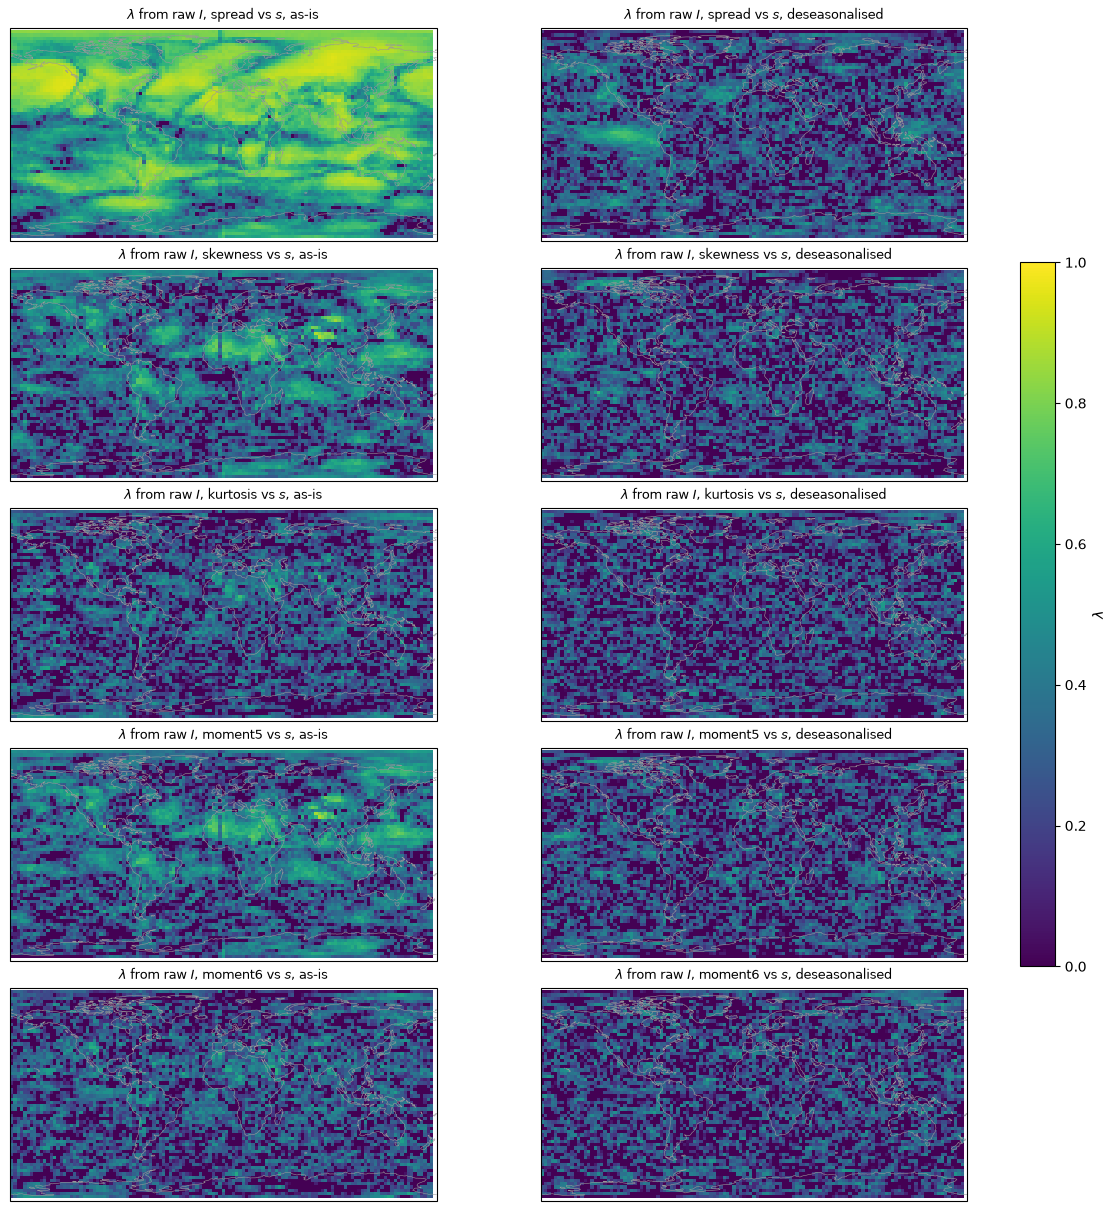

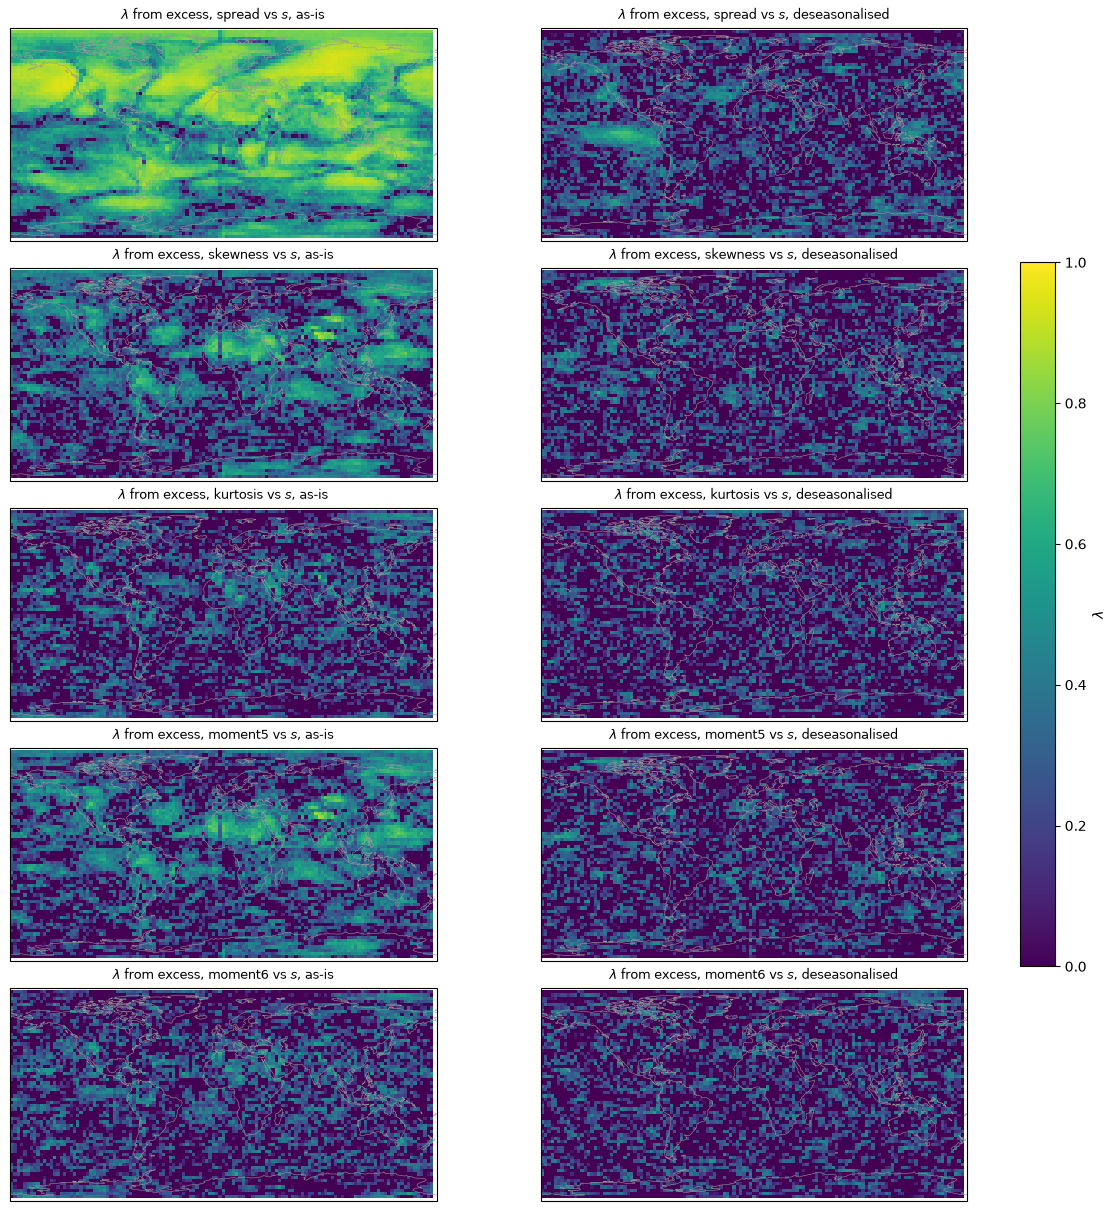

moment     version          lam(raw)  lam(exc)   %lam=0
spread     as-is               0.630     0.603     3.5%
spread     deseasonalised      0.225     0.160    42.3%
skewness   as-is               0.315     0.256    27.0%
skewness   deseasonalised      0.195     0.133    48.8%
kurtosis   as-is               0.220     0.156    43.2%
kurtosis   deseasonalised      0.183     0.121    51.7%
moment5    as-is               0.303     0.244    28.9%
moment5    deseasonalised      0.189     0.128    50.4%
moment6    as-is               0.217     0.152    44.6%
moment6    deseasonalised      0.180     0.120    52.0%


In [5]:
def lam_clamped(I):
    return np.sqrt(np.maximum(0.0, 1.0 - 2.0 ** (-2.0 * I)))


assert np.allclose(lam_clamped(np.linspace(-0.3, 1.0, 9)),
                   R.lam(np.linspace(-0.3, 1.0, 9)))

NORM = Normalize(0, 1)
for label, idx, tag_ in (("$\\lambda$ from raw $I$", 0, "raw"),
                         ("$\\lambda$ from excess", 2, "excess")):
    fig, axs = plt.subplots(len(MOMENTS), 2, figsize=(12, 2.4 * len(MOMENTS)),
                            layout="constrained", subplot_kw={"projection": PROJ})
    for i, (nm, _) in enumerate(MOMENTS):
        for j, tag in enumerate(VERSIONS):
            h = panel(axs[i, j], lam_clamped(fields(nm, tag)[idx]), "viridis", NORM,
                      "%s, $\\mathrm{%s}$ vs $s$, %s" % (label, nm, tag))
    fig.colorbar(h, ax=axs, shrink=0.6, label="$\\lambda$")
    plt.show()

print("%-10s %-15s %9s %9s %8s" % ("moment", "version", "lam(raw)", "lam(exc)", "%lam=0"))
for nm, _ in MOMENTS:
    for tag in VERSIONS:
        lr = lam_clamped(fields(nm, tag)[0])
        le = lam_clamped(fields(nm, tag)[2])
        print("%-10s %-15s %9.3f %9.3f %7.1f%%"
              % (nm, tag, np.nanmean(lr), np.nanmean(le), 100 * np.mean(le == 0)))

## Pearson $r$ maps

$r$ between each moment and $s$ along the time axis. Signed, and linear only, where
$\lambda$ is unsigned and responds to any monotone relationship. Colour scale $\pm0.6$;
the as-is spread panel saturates against it.

`crit` is the naive 95% threshold $1.96/\sqrt{T-3}$, which ignores autocorrelation.

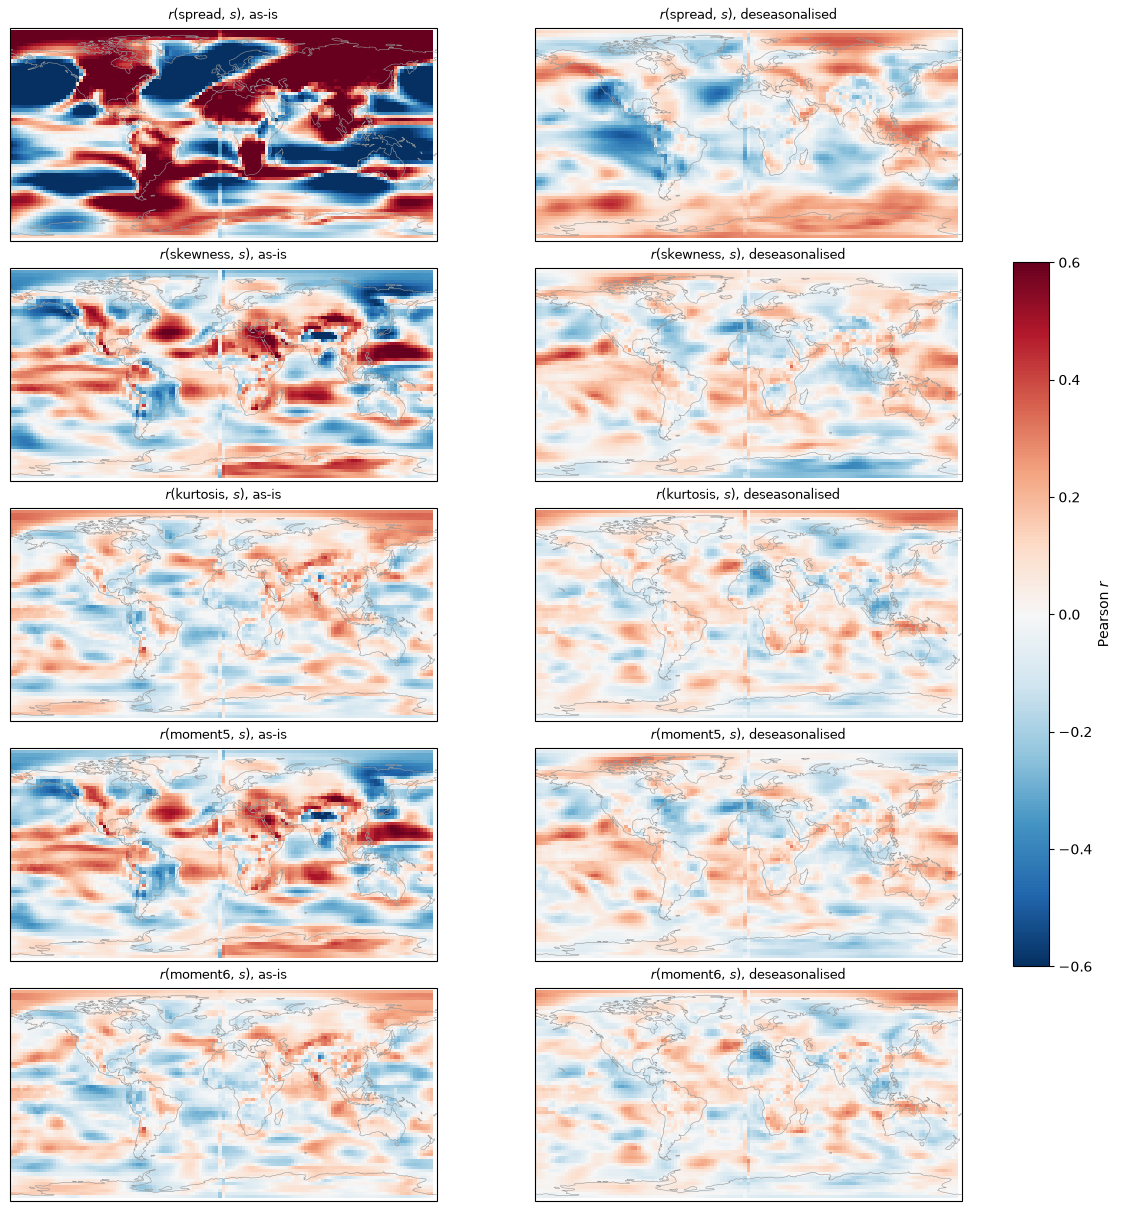

crit = 0.181

moment     version           mean r  mean|r|  %|r|>crit corr(|r|,lam)
spread     as-is             +0.066    0.438      78.1%     0.744
spread     deseasonalised    +0.019    0.146      30.9%     0.377
skewness   as-is             +0.009    0.186      44.6%     0.614
skewness   deseasonalised    +0.016    0.102      16.8%     0.221
kurtosis   as-is             +0.013    0.111      19.6%     0.292
kurtosis   deseasonalised    +0.012    0.085       8.6%     0.160
moment5    as-is             +0.011    0.165      41.5%     0.558
moment5    deseasonalised    +0.012    0.092      12.9%     0.213
moment6    as-is             +0.006    0.103      17.4%     0.255
moment6    deseasonalised    +0.008    0.081       8.3%     0.158


In [6]:
def pearson(A, B):
    a = A - A.mean(axis=0, keepdims=True)
    b = B - B.mean(axis=0, keepdims=True)
    den = np.sqrt((a ** 2).sum(axis=0) * (b ** 2).sum(axis=0))
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(den > 0, (a * b).sum(axis=0) / np.where(den > 0, den, 1), np.nan)


RR = {}
for nm, M in MOMENTS:
    RR["%s|as-is" % nm] = pearson(M, SGN)
    RR["%s|deseasonalised" % nm] = pearson(deseason(M), SGN_ds)

crit = 1.96 / np.sqrt(SGN.shape[0] - 3)

fig, axs = plt.subplots(len(MOMENTS), 2, figsize=(12, 2.4 * len(MOMENTS)),
                        layout="constrained", subplot_kw={"projection": PROJ})
for i, (nm, _) in enumerate(MOMENTS):
    for j, tag in enumerate(VERSIONS):
        h = panel(axs[i, j], RR["%s|%s" % (nm, tag)], "RdBu_r", Normalize(-0.6, 0.6),
                  "$r(\\mathrm{%s},\\,s)$, %s" % (nm, tag))
fig.colorbar(h, ax=axs, shrink=0.6, label="Pearson $r$")
plt.show()

print("crit = %.3f\n" % crit)
print("%-10s %-15s %8s %8s %10s %9s"
      % ("moment", "version", "mean r", "mean|r|", "%|r|>crit", "corr(|r|,lam)"))
for nm, _ in MOMENTS:
    for tag in VERSIONS:
        r = RR["%s|%s" % (nm, tag)]
        lam = lam_clamped(fields(nm, tag)[2])
        m = np.isfinite(r) & np.isfinite(lam)
        print("%-10s %-15s %+8.3f %8.3f %9.1f%% %9.3f"
              % (nm, tag, np.nanmean(r), np.nanmean(np.abs(r)),
                 100 * R.area_weighted_fraction(np.abs(r), lats, threshold=crit),
                 np.corrcoef(np.abs(r)[m], lam[m])[0, 1]))

### Mean $r$ by latitude band

Mean $r$ over $\cos(\mathrm{lat})$ bands, for the as-is fields.

In [7]:
bands = [(0, 15), (15, 30), (30, 60), (60, 90)]
print("%-10s %s" % ("moment", "  ".join("%2d-%2d" % b for b in bands)))
for nm, _ in MOMENTS:
    r = RR["%s|as-is" % nm]
    print("%-10s %s" % (nm, "  ".join(
        "%+.3f" % np.nanmean(r[(np.abs(lats) >= a) & (np.abs(lats) < b)])
        for a, b in bands)))

moment      0-15  15-30  30-60  60-90
spread     -0.021  -0.001  -0.017  +0.243
skewness   +0.066  +0.117  -0.035  -0.036
kurtosis   -0.024  -0.022  +0.029  +0.035
moment5    +0.069  +0.103  -0.036  -0.022
moment6    -0.033  -0.028  +0.022  +0.028


### Redundancy between moments

Correlation of the moment time series with each other, and of the $r(\cdot,s)$ maps with
each other.

In [8]:
pairs = [("skewness", M3), ("kurtosis", M4), ("moment5", M5), ("moment6", M6)]
print("%-22s %10s %10s" % ("pair", "series r", "map r"))
for i, (na, A) in enumerate(pairs):
    for nb_, B in pairs[i + 1:]:
        a, b = RR["%s|as-is" % na], RR["%s|as-is" % nb_]
        m = np.isfinite(a) & np.isfinite(b)
        print("%-22s %+10.3f %+10.3f"
              % ("%s / %s" % (na, nb_), np.nanmean(pearson(A, B)),
                 np.corrcoef(a[m], b[m])[0, 1]))

pair                     series r      map r
skewness / kurtosis        +0.025     -0.235
skewness / moment5         +0.927     +0.983
skewness / moment6         +0.023     -0.223
kurtosis / moment5         +0.028     -0.241
kurtosis / moment6         +0.961     +0.974
moment5 / moment6          +0.026     -0.233
